In [1]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

Mounted at /content/drive


In [4]:
# Determine the path to data folders in Google Drive
train_dir = '/content/drive/MyDrive/Project_BrainTumor/Training'
test_dir = '/content/drive/MyDrive/Project_BrainTumor/Testing'

# Preprocessing settings (resize images to 224x224 pixels)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training data generator (with random variations to diversify the data)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    horizontal_flip=True
)

# Test data generator (color normalization only, no random variations)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load images from folders
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [5]:
# Load the base model (without the last classification layer)
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze base layers
base_model.trainable = False

# Adding proprietary layers to detect 4 categories of brain tumors
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

# Output layer with 4 neurons (for 4 categories: glioma, meningioma, pituitary, healthy)
predictions = Dense(4, activation='softmax')(x)

# Combine the base model and new layers
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model (determine how to calculate error and optimize)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary() # Show model structure

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
# Training process
history = model.fit(
    train_data,
    epochs=15,
    validation_data=test_data
)

Epoch 1/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 548ms/step - accuracy: 0.9432 - loss: 0.1646 - val_accuracy: 0.7208 - val_loss: 1.9353
Epoch 2/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 78s 508ms/step - accuracy: 0.9463 - loss: 0.1456 - val_accuracy: 0.7183 - val_loss: 1.7835
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 510ms/step - accuracy: 0.9495 - loss: 0.1362 - val_accuracy: 0.7208 - val_loss: 1.7310
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 81s 501ms/step - accuracy: 0.9523 - loss: 0.1378 - val_accuracy: 0.7183 - val_loss: 2.2194
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 514ms/step - accuracy: 0.9502 - loss: 0.1306 - val_accuracy: 0.7589 - val_loss: 2.0627
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 47s 526ms/step - accuracy: 0.9613 - loss: 0.1061 - val_accuracy: 0.7538 - val_loss: 1.9522
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 507ms/step - accuracy: 0.9571 - loss: 0.1147 - val_accuracy: 0.7513 - val_loss: 2.0640
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 46s 511ms/step - accuracy: 0.9624 - loss: 0.1051 - val_accu

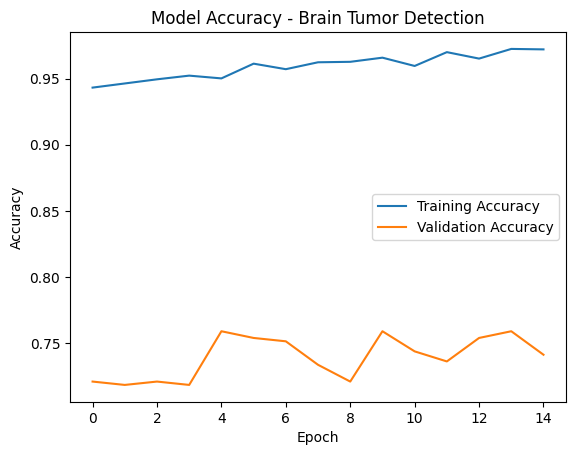

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.7411 - loss: 2.7743
Final Test Accuracy: 74.11%


In [11]:
#Accuracy chart
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy - Brain Tumor Detection')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Final evaluation of the model on test data
loss, accuracy = model.evaluate(test_data)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")